Emre Alca
title: Hopfield Barrier Demo.ipynb
date: 2025-01-18 11:52:19

In [38]:
from linearframework.linear_framework_graph import LinearFrameworkGraph
import linearframework.linear_framework_results as lfr

from tqdm import tqdm
import networkx as nx
import sympy as sp
from math import factorial
import numpy as np
import matplotlib.pyplot as plt

This notebook builds on the notes: "A conjecture for the refinement of the Aldous-Shepp theorem" found in this folder.

Let's recall from that note, that we are trying to show that for any graph with $n > 1$ vertices $G_n$, it's generalized randomness parameter $s_m(G)$ is bounded below by the generalized randomness parameter on the Erlang Process:
$$
    s_m(G_n) \geq s_m(E_n).
$$
or more explicitly
$$
    \frac{\langle t(G)^m \rangle}{\langle t(G) \rangle^m} \geq \frac{\prod_{j=0}^{m-1} (n-1+j)}{(n-1)^m}
$$

Let's begin by generating a random graph using networkx

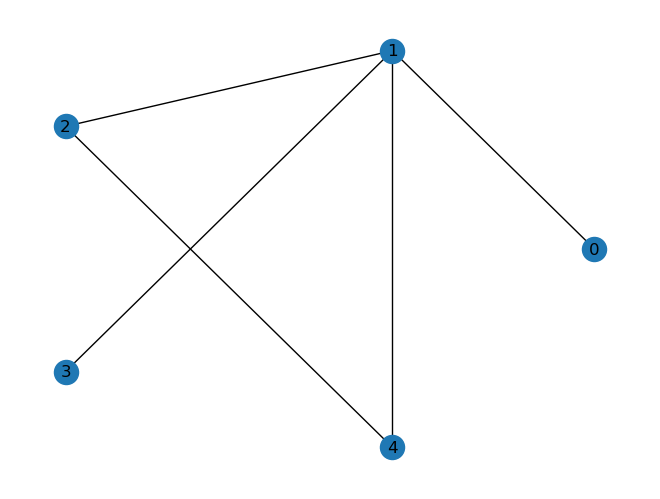

In [12]:
num_vertices = 5
edge_probability = 0.5

random_nx_graph = nx.erdos_renyi_graph(num_vertices, edge_probability, directed=False)

nx.draw_circular(random_nx_graph, with_labels=True)

Let's make sure there is a path from the source to the target. If this is false, we need to choose a different source, target, or generate a new graph to ensure there is a path from the source to the target. Otherwise the generalized randomness parameter is not well defined.

In [13]:
source = 0
target = 4

nx.has_path(random_nx_graph, source, target)

True

One current limitation of LinearFramework.py is that we can only calculate the higher moments of graphs which have no terminal vertices. This paradigm can still approximate graphs with terminal vertices by setting one direction of a transition to be much higher than it's reverse, but terminal functionality is upcoming.

So we take each edge in both directions 

In [14]:
bidirectional_edges = list(random_nx_graph.edges)

for edge in bidirectional_edges.copy():
    bidirectional_edges.append((edge[1], edge[0]))

bidirectional_edges

[(0, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 4),
 (1, 0),
 (2, 1),
 (3, 1),
 (4, 1),
 (4, 2)]

We can turn this nx graph into a LinearFrameworkGraph

In [15]:
random_graph = LinearFrameworkGraph(bidirectional_edges)

With this graph in mind, we can calculate our randomness parameter. Do note that this calculation can be fairly computationally expensive

In [16]:
moment = 2

generalized_randomness_param_numerator = lfr.k_moment_fpt_expression(random_graph, source, target, moment)
generalized_randomness_param_denominator = lfr.k_moment_fpt_expression(random_graph, source, target, 1) ** moment

generalized_randomness_param = generalized_randomness_param_numerator / generalized_randomness_param_denominator

sp.simplify(generalized_randomness_param)

2*(l_1**2*l_2**2*l_8**2 + l_1**2*l_2*l_3*l_5**2 + l_1**2*l_2*l_3*l_5*l_7 + l_1**2*l_2*l_3*l_5*l_8 + 2*l_1**2*l_2*l_3*l_7*l_8 + l_1**2*l_2*l_4*l_8**2 + l_1**2*l_2*l_5*l_8**2 + 2*l_1**2*l_2*l_7*l_8**2 + l_1**2*l_3**2*l_5**2 + 2*l_1**2*l_3**2*l_5*l_7 + l_1**2*l_3**2*l_7**2 + l_1**2*l_3*l_4*l_5**2 + 2*l_1**2*l_3*l_4*l_5*l_7 + l_1**2*l_3*l_4*l_7**2 + 2*l_1**2*l_3*l_5**2*l_8 + 4*l_1**2*l_3*l_5*l_7*l_8 + 2*l_1**2*l_3*l_7**2*l_8 + l_1**2*l_5**2*l_8**2 + 2*l_1**2*l_5*l_7*l_8**2 + l_1**2*l_7**2*l_8**2 + l_1*l_2**2*l_5*l_8**2 + l_1*l_2*l_3*l_5**2*l_8 + l_1*l_2*l_3*l_5*l_7*l_8 + l_1*l_2*l_4*l_5*l_8**2 + l_1*l_2*l_4*l_7*l_8**2 + l_1*l_2*l_5**2*l_8**2 + l_1*l_2*l_5*l_6*l_8**2 + l_1*l_2*l_5*l_7*l_8**2 + 2*l_1*l_2*l_6*l_7*l_8**2 + l_1*l_3*l_4*l_5**2*l_8 + 2*l_1*l_3*l_4*l_5*l_7*l_8 + l_1*l_3*l_4*l_7**2*l_8 + 2*l_1*l_3*l_5**2*l_6*l_8 + 4*l_1*l_3*l_5*l_6*l_7*l_8 + 2*l_1*l_3*l_6*l_7**2*l_8 + l_1*l_4*l_5**2*l_8**2 + 2*l_1*l_4*l_5*l_7*l_8**2 + l_1*l_4*l_7**2*l_8**2 + 2*l_1*l_5**2*l_6*l_8**2 + 4*l_1*l_5*l_6*

Now let's also calculate our expected bound:

In [17]:
def generalized_randomness_param_erlang(n, m):
    """
    calculates the m-th generalized randomness parameter of an erlang process on n vertices

    Args:
        n (int): the number of vertices in the erlang process.
        m (int): the moment in the numerator, and the exponent in the denominator of the generalized randomness parameter.

    Returns:
        float: the m-th generalized randomness parameter of an erlang process on n vertices
    """
    
    numerator = factorial(n + m - 2)

    denominator = factorial(n - 2)
    denominator *= (n-1)**m
    return numerator / denominator

expected_lower_bound = generalized_randomness_param_erlang(num_vertices, moment)

expected_lower_bound

1.25

There are tools built into linearframework.py that make it easier to perform monte-carlo simulations.

There is a method for `LinearFrameworkGraph` objects which allows you to input a specific `edge_to_weight` dictionary, and get a `sym_to_weight` dictionary you can use to evaluate your symbolic expression at a point.

Let's try with a uniformly sampled `edge_to_weight` dictionary

In [27]:
edge_to_weight = random_graph.generate_random_edge_to_weight()

sym_to_weight = random_graph.make_sym_to_weight(edge_to_weight)

sym_to_weight

{l_1: 0.08282611997161919,
 l_2: 2.4906474158833616,
 l_3: 3.926365925098384,
 l_4: 3.3452897918522946,
 l_5: 0.008640399277363958,
 l_6: 3.778863886794464,
 l_7: 0.0021572014869574384,
 l_8: 949.068403627478,
 l_9: 0.0010899783816965553,
 l_10: 2.254418783349476}

Or, if we run `graph.make_sym_to_weight()` with no arguments, the function calls `graph.generate_random_edge_to_weight()` automatically

In [28]:
sym_to_weight = random_graph.make_sym_to_weight()

sym_to_weight

{l_1: 0.6561146493726775,
 l_2: 3.6039516643899936,
 l_3: 1.4274684666761304,
 l_4: 0.8320512177004247,
 l_5: 0.0012985463959282165,
 l_6: 0.5225327910175577,
 l_7: 11.30580639169005,
 l_8: 189.90591736637245,
 l_9: 2.537856944457659,
 l_10: 0.012284677082879064}

In [29]:
generalized_randomness_param.subs(sym_to_weight)

1.71147232077964

And we can repeat this a number of times.

In [50]:
num_samples = 1000

data_points = []

for sample in tqdm(range(num_samples)):
    new_sym_to_weight = random_graph.make_sym_to_weight()

    new_point = generalized_randomness_param.subs(new_sym_to_weight)

    data_points.append(new_point)

# data_points

100%|██████████| 1000/1000 [02:31<00:00,  6.60it/s]


And then we can plot these points, in comparison with our expected lower bound

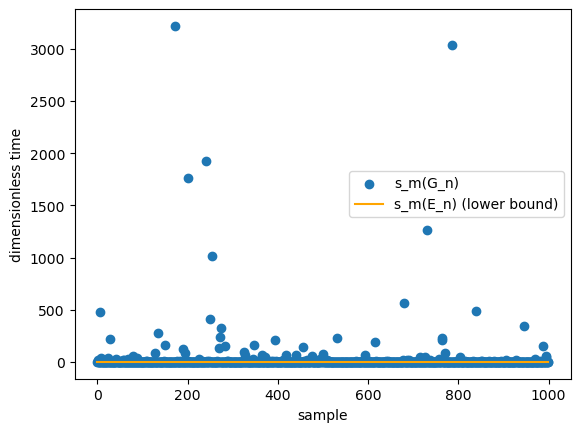

In [51]:
plt.scatter(np.arange(num_samples), data_points, label='s_m(G_n)')
plt.plot(np.ones(num_samples)*expected_lower_bound, label='s_m(E_n) (lower bound)', color='orange')
plt.legend()
plt.ylabel('dimensionless time')
plt.xlabel('sample')
plt.show()

we can also check numerically whether our bound is violated.

If the following statement is True, the bound is violated

In [53]:
min(data_points) < expected_lower_bound

False